In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("customer_support_text_classification.csv")

# Show first 5 rows
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [2]:
# Dataset shape
print("Rows and Columns:", df.shape)

Rows and Columns: (1500, 6)


In [3]:
# Target labels
print(df['sentiment_label'].unique())

# Count classes
print(df['sentiment_label'].value_counts())

['neutral' 'positive' 'negative']
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [4]:
# Sample text records
df[['customer_message', 'sentiment_label']].head()

,customer_message,sentiment_label
0,I need information about the payment process. ...,neutral
1,I need information about the payment process.,neutral
2,The refund process was fast and convenient. I ...,positive
3,My refund is still pending and this experience...,negative
4,Please tell me how to update my account details.,neutral


In [5]:
# Average text length
df['text_length'] = df['customer_message'].apply(len)

print(
    "Average Text Length:",
    df['text_length'].mean()
)

Average Text Length: 72.75666666666666


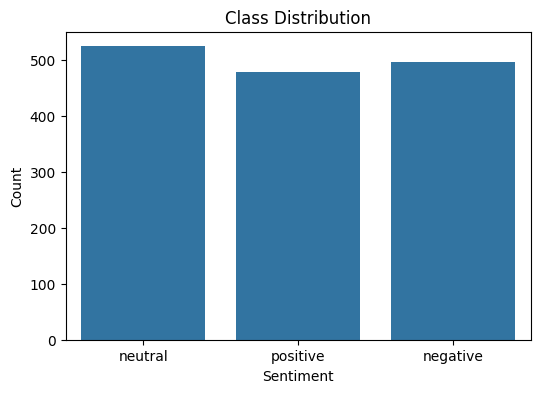

In [6]:
# Class distribution graph
plt.figure(figsize=(6,4))

sns.countplot(
    x='sentiment_label',
    data=df
)

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [9]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
import re
import nltk

from nltk.corpus import stopwords

# Download resources
nltk.download('stopwords')

# Stopwords
stop_words = set(stopwords.words('english'))

# Cleaning function
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Simple tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Join back
    return " ".join(tokens)

# Apply cleaning
df['cleaned_text'] = df[
    'customer_message'
].apply(clean_text)

# Show sample
df[['customer_message',
    'cleaned_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,customer_message,cleaned_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


In [11]:
print("Original Text:")
print(df['customer_message'][0])

print("\nCleaned Text:")
print(df['cleaned_text'][0])

Original Text:
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Cleaned Text:
need information payment process ticket number please respond soon possible


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(
    df['cleaned_text']
)

# Target labels
y = df['sentiment_label']

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (1500, 146)


In [13]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Encoded Labels:")
print(np.unique(y))

Encoded Labels:
[0 1 2]


In [14]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1200, 146)
Testing Shape: (300, 146)


In [15]:
from sklearn.linear_model import LogisticRegression

# Create model
baseline_model = LogisticRegression()

# Train model
baseline_model.fit(
    X_train,
    y_train
)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [16]:
# Predictions
y_pred = baseline_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Model Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Model Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00       105
           2       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



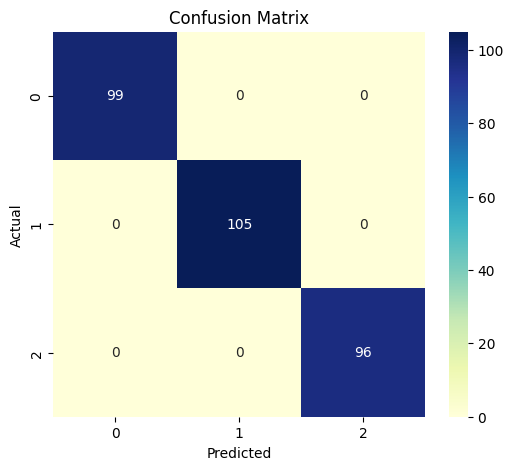

In [18]:
# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenizer
tokenizer = Tokenizer(
    num_words=5000
)

tokenizer.fit_on_texts(
    df['cleaned_text']
)

# Convert text to sequences
X_seq = tokenizer.texts_to_sequences(
    df['cleaned_text']
)

# Padding sequences
max_length = 50

X_seq = pad_sequences(
    X_seq,
    maxlen=max_length,
    padding='post'
)

print("Sequence Shape:", X_seq.shape)

Sequence Shape: (1500, 50)


In [20]:
# Split sequence data
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train_seq.shape)
print("Testing Shape:", X_test_seq.shape)

Training Shape: (1200, 50)
Testing Shape: (300, 50)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Build LSTM model
lstm_model = Sequential()

# Embedding layer
lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=64,
        input_length=max_length
    )
)

# LSTM layer
lstm_model.add(
    LSTM(64)
)

# Output layer
lstm_model.add(
    Dense(3, activation='softmax')
)

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train LSTM model

history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.3344 - loss: 1.0985 - val_accuracy: 0.3375 - val_loss: 1.1054
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.3521 - loss: 1.0988 - val_accuracy: 0.3375 - val_loss: 1.1014
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3406 - loss: 1.0987 - val_accuracy: 0.3375 - val_loss: 1.1001
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3521 - loss: 1.0980 - val_accuracy: 0.3375 - val_loss: 1.1024
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3521 - loss: 1.0979 - val_accuracy: 0.3375 - val_loss: 1.1018


In [23]:
# Evaluate LSTM model

test_loss, test_accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("LSTM Test Accuracy:", test_accuracy)
print("LSTM Test Loss:", test_loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3500 - loss: 1.0981
LSTM Test Accuracy: 0.3499999940395355
LSTM Test Loss: 1.0981121063232422


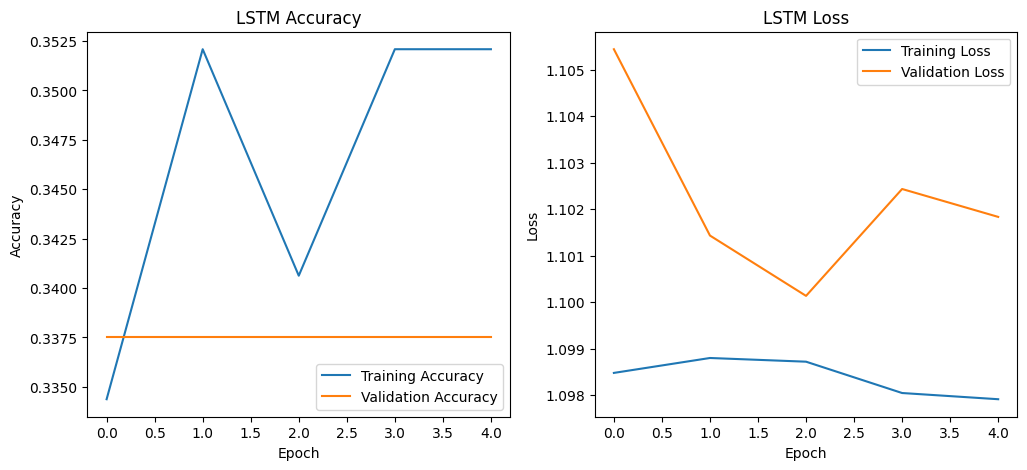

In [24]:
plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(
    history_lstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Task 6: Attention and Transformer Reflection

## 1. Why RNNs Struggle with Long-Term Dependencies

Recurrent Neural Networks (RNNs) struggle with long-term dependencies because information from earlier words gradually becomes weaker as sequences become longer. This happens due to the vanishing gradient problem, making it difficult for RNNs to remember important context from distant words.

---

## 2. How LSTMs Help with Memory

Long Short-Term Memory (LSTM) networks improve memory by introducing gates such as input gate, forget gate, and output gate. These gates help the model decide what information should be remembered or forgotten, making LSTMs better at handling long text sequences compared to traditional RNNs.

---

## 3. What Attention Solves in Sequence-to-Sequence Tasks

Attention mechanisms help models focus on the most important words in a sequence instead of relying only on previous hidden states. This improves performance in tasks like machine translation, summarization, and text generation by allowing the model to selectively focus on relevant information.

---

## 4. Why Transformers are Important in Modern NLP and Generative AI

Transformers are important because they process entire sequences in parallel and use attention mechanisms to understand relationships between words efficiently. They are faster and more powerful than RNNs and LSTMs. Modern Generative AI systems such as ChatGPT, GPT models, and large language models are based on transformer architectures.

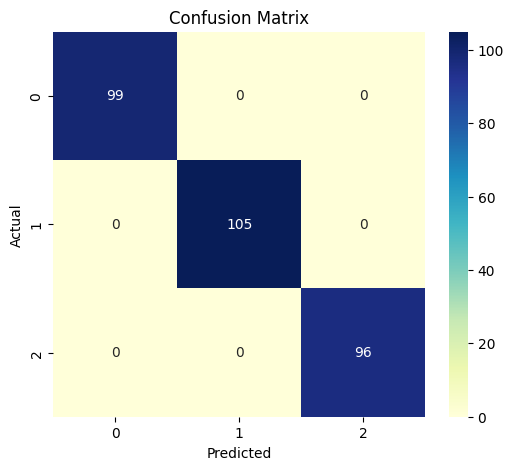

In [25]:
import os

os.makedirs(
    "part-3-nlp-sequence-modeling/results",
    exist_ok=True
)

# Save confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "part-3-nlp-sequence-modeling/results/model_evaluation.png"
)

plt.show()

In [26]:
# Decode labels
label_names = encoder.inverse_transform(y_pred[:10])

actual_names = encoder.inverse_transform(y_test[:10])

# Save predictions
with open(
    "part-3-nlp-sequence-modeling/results/sample_predictions.txt",
    "w"
) as f:

    for i in range(10):
        f.write(
            f"Actual: {actual_names[i]} | Predicted: {label_names[i]}\n"
        )

print("Sample predictions saved!")

Sample predictions saved!


In [27]:
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
tensorflow
nltk
"""

with open(
    "part-3-nlp-sequence-modeling/requirements.txt",
    "w"
) as f:
    f.write(requirements)

print("requirements.txt created!")

requirements.txt created!
